# SuperSimpleNet

In [1]:
import os
import re
import copy
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
from torch.optim.lr_scheduler import MultiStepLR

from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel

from sklearn.metrics import average_precision_score, roc_auc_score


c:\Users\AERO\Desktop\master_work\FastFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)


Device: cuda


# Конфигурация

In [ ]:
dataset_path = "datasets/processed_printer_dataset"
image_size = 256

max_train_images_per_date = 200
max_val_images_per_date = 100
num_train_epochs = 30

logs_folder = "3D_printer_supersimplenet_head_finetune"
try_number = 3
log_dir = os.path.join("../experiments", logs_folder, f"try_{try_number}")


# Преобразования

In [4]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.1), ratio=(1, 1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def postprocess_anomaly_map(anomaly_map, true_img_size):
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)

    upsampled_mask = torch_f.interpolate(
        anomaly_map,
        size=true_img_size,
        mode="bilinear",
        align_corners=False
    )
    return upsampled_mask.squeeze()


# Датасеты

In [5]:
class PrinterTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None, include_dates=None, exclude_dates=None, max_images_per_date=None, seed=42):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.dates = []

        include_dates = set(include_dates) if include_dates is not None else None
        exclude_dates = set(exclude_dates) if exclude_dates is not None else set()

        for date_dir in sorted(os.listdir(self.root_dir)):
            if include_dates is not None and date_dir not in include_dates:
                continue
            if date_dir in exclude_dates:
                continue

            objects_dir = os.path.join(self.root_dir, date_dir, "objects_parts")
            if os.path.isdir(objects_dir):
                date_image_paths = []
                for img_name in sorted(os.listdir(objects_dir)):
                    if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                        date_image_paths.append(os.path.join(objects_dir, img_name))

                if max_images_per_date is not None and len(date_image_paths) > max_images_per_date:
                    rng = random.Random(f"{seed}_{date_dir}")
                    date_image_paths = sorted(rng.sample(date_image_paths, max_images_per_date))

                self.image_paths.extend(date_image_paths)
                self.dates.extend([date_dir] * len(date_image_paths))

        print(f"Loaded {len(self.image_paths)} object fragments from {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


def anomaly_index_from_name(name):
    match = re.fullmatch(r"anomaly_(\d+)\.(png|jpg|jpeg)", name.lower())
    return int(match.group(1)) if match else None


def is_good_visual_image(name):
    return re.fullmatch(r"good_\d+\.(png|jpg|jpeg)", name.lower()) is not None


def is_visual_test_anomaly(name, max_index=16):
    anomaly_index = anomaly_index_from_name(name)
    return anomaly_index is not None and anomaly_index <= max_index


def is_head_finetune_anomaly(name, min_index=17):
    anomaly_index = anomaly_index_from_name(name)
    return anomaly_index is not None and anomaly_index >= min_index


def is_visual_test_image(name):
    return is_good_visual_image(name) or is_visual_test_anomaly(name)


def visual_test_label_from_name(name):
    if is_good_visual_image(name):
        return 0
    if is_visual_test_anomaly(name):
        return 1
    raise ValueError(f"{name} is not a visual-test image")


class ImageFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None, return_names=False, recursive=False, filename_filter=None):
        self.root_dir = root_dir
        self.transform = transform
        self.return_names = return_names
        self.image_paths = []

        walker = os.walk(root_dir) if recursive else [(root_dir, [], os.listdir(root_dir))]
        for current_dir, _, files in walker:
            for img_name in sorted(files):
                if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                if filename_filter is not None and not filename_filter(img_name):
                    continue
                self.image_paths.append(os.path.join(current_dir, img_name))

        print(f"Loaded {len(self.image_paths)} images from {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.return_names:
            return image, os.path.basename(self.image_paths[idx])
        return image


class LabeledImageFolderDataset(ImageFolderDataset):
    def __init__(self, root_dir, transform=None, return_names=False, recursive=False, filename_filter=None, label_fn=None):
        super().__init__(root_dir, transform=transform, return_names=False, recursive=recursive, filename_filter=filename_filter)
        self.return_names = return_names
        self.label_fn = label_fn

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        name = os.path.basename(self.image_paths[idx])
        label = self.label_fn(name) if self.label_fn else 0
        if self.return_names:
            return image, label, name
        return image, label


def get_date_split(root_dir, validation_fraction=0.2):
    dates = []
    for date_dir in sorted(os.listdir(root_dir)):
        objects_dir = os.path.join(root_dir, date_dir, "objects_parts")
        if os.path.isdir(objects_dir):
            dates.append(date_dir)

    val_count = max(1, int(round(len(dates) * validation_fraction)))
    val_dates = dates[-val_count:]
    train_dates = dates[:-val_count]
    return train_dates, val_dates


In [6]:
train_root = os.path.join(dataset_path, "training")
visual_test_dir = os.path.join(dataset_path, "visual_test_images")
train_dates, val_dates = get_date_split(train_root, validation_fraction=0.2)
print(f"Train dates: {train_dates}")
print(f"Validation dates: {val_dates}")

train_dataset = PrinterTrainDataset(
    train_root,
    transform=get_transformer(image_size),
    include_dates=train_dates,
    max_images_per_date=max_train_images_per_date,
    seed=random_seed,
)

normal_val_dataset = PrinterTrainDataset(
    train_root,
    transform=get_transformer(image_size),
    include_dates=val_dates,
    max_images_per_date=max_val_images_per_date,
    seed=random_seed,
)

visualization_dataset = ImageFolderDataset(
    visual_test_dir,
    transform=get_transformer(image_size),
    return_names=True,
    filename_filter=is_visual_test_image,
)

visual_test_classification_dataset = LabeledImageFolderDataset(
    visual_test_dir,
    transform=get_transformer(image_size),
    return_names=True,
    filename_filter=is_visual_test_image,
    label_fn=visual_test_label_from_name,
)

anomalies_dataset = ImageFolderDataset(
    visual_test_dir,
    transform=get_transformer(image_size),
    return_names=True,
    filename_filter=is_visual_test_anomaly,
)

head_finetune_anomaly_dataset = ImageFolderDataset(
    visual_test_dir,
    transform=get_transformer(image_size),
    return_names=True,
    filename_filter=is_head_finetune_anomaly,
)

print(f"Visual test images: {len(visualization_dataset)}")
print(f"Held-out visual anomalies for test: {len(anomalies_dataset)}")
print(f"Anomalies reserved for classifier-head fine-tune: {len(head_finetune_anomaly_dataset)}")


Train dates: ['2024-12-16', '2025-01-15', '2025-01-29', '2025-02-07', '2025-03-21', '2025-04-02', '2025-05-26', '2025-05-28']
Validation dates: ['2025-06-25', '2025-06-30']
Loaded 1102 object fragments from datasets/processed_printer_dataset\training
Loaded 200 object fragments from datasets/processed_printer_dataset\training
Loaded 31 images from datasets/processed_printer_dataset\visual_test_images
Loaded 31 images from datasets/processed_printer_dataset\visual_test_images
Loaded 16 images from datasets/processed_printer_dataset\visual_test_images
Loaded 17 images from datasets/processed_printer_dataset\visual_test_images
Visual test images: 31
Held-out visual anomalies for test: 16
Anomalies reserved for classifier-head fine-tune: 17


# Визуализация и метрики

In [7]:
def img2mask(img):
    mask = img if img.ndim <= 2 else img.squeeze()
    if mask.ndim == 3:
        mask = mask[0, :, :]
    if mask.ndim != 2:
        raise ValueError("Wrong dimensions")
    return mask


def predict_label(pred_anomaly_map, k=0.001):
    pred_anomaly_map = img2mask(pred_anomaly_map)
    y_scores = pred_anomaly_map.flatten().cpu()
    top_k = max(1, int(k * len(y_scores)))
    return torch.mean(torch.topk(y_scores, top_k).values)


def predict_image_score(model, img):
    model.eval()
    with torch.no_grad():
        output = model(img)
        return output.pred_score.item()


def predict_with_augmentations(model, img, true_img_size=None):
    aug_anomaly_maps = []

    with torch.no_grad():
        output = model(img)
        aug_anomaly_maps.append(torch.sigmoid(output.anomaly_map))

        img_flip_h = torch.flip(img, dims=[-1])
        output_flip_h = model(img_flip_h)
        anomaly_map_flip_h = torch.flip(torch.sigmoid(output_flip_h.anomaly_map), dims=[-1])
        aug_anomaly_maps.append(anomaly_map_flip_h)

        img_flip_v = torch.flip(img, dims=[-2])
        output_flip_v = model(img_flip_v)
        anomaly_map_flip_v = torch.flip(torch.sigmoid(output_flip_v.anomaly_map), dims=[-2])
        aug_anomaly_maps.append(anomaly_map_flip_v)

    anomaly_map = torch.mean(torch.stack(aug_anomaly_maps), dim=0)
    if true_img_size is not None:
        anomaly_map = postprocess_anomaly_map(anomaly_map, true_img_size=true_img_size)
    return anomaly_map


def plot_training_curves(metrics, metric_names, log_dir, plot_name, log_y=False):
    os.makedirs(log_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.title("Training metrics")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, plot_name))
    plt.show()


def visualize_results(original_image, anomaly_map, save_path=None, score=None, figsize=(10, 4), alpha=0.7, cmap="jet"):
    denormalize = transforms.Compose([
        transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
    ])

    original_image = denormalize(original_image.squeeze().detach().cpu())
    original_image = torch.clamp(original_image, 0, 1)
    anomaly_map = img2mask(anomaly_map.detach().cpu())

    original_image = transforms.ToPILImage()(original_image)
    anomaly_map = anomaly_map.numpy()

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(original_image)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(original_image)
    heatmap = axes[1].imshow(anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    title = "Input + Anomaly Map"
    if score is not None:
        title += f" | score={score:.4f}"
    axes[1].set_title(title)
    axes[1].axis("off")
    plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close(fig)
    else:
        plt.show()


def sigmoid_score(logit):
    return torch.sigmoid(torch.as_tensor(logit)).item()


def evaluate_visual_test(model, dataset, log_dir, image_size, device=device, eval_subdir="final_eval"):
    final_eval_dir = os.path.join(log_dir, eval_subdir)
    visualizations_dir = os.path.join(final_eval_dir, "visualizations")
    os.makedirs(visualizations_dir, exist_ok=True)

    model.eval()
    rows = []
    true_labels = []
    predicted_scores = []

    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Final Visual Test", leave=False):
            img, true_label, name = dataset[i]
            img = img.unsqueeze(0).to(device)

            raw_score = predict_image_score(model, img)
            image_score = sigmoid_score(raw_score)
            anomaly_map = predict_with_augmentations(model, img, true_img_size=(image_size, image_size))

            visualize_results(
                img,
                anomaly_map,
                save_path=os.path.join(visualizations_dir, name),
                score=image_score,
            )

            row = {
                "name": name,
                "label": int(true_label),
                "raw_pred_score": float(raw_score),
                "image_score": float(image_score),
            }
            rows.append(row)
            true_labels.append(int(true_label))
            predicted_scores.append(float(image_score))

    metrics = {
        "image_roc_auc": float(roc_auc_score(true_labels, predicted_scores)),
        "image_avg_precision": float(average_precision_score(true_labels, predicted_scores)),
        "num_images": len(rows),
        "num_good": int(sum(1 for label in true_labels if label == 0)),
        "num_anomaly": int(sum(1 for label in true_labels if label == 1)),
    }

    with open(os.path.join(final_eval_dir, "per_image_scores.csv"), "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["name", "label", "raw_pred_score", "image_score"])
        writer.writeheader()
        writer.writerows(rows)

    with open(os.path.join(final_eval_dir, "classification_metrics.txt"), "w") as f:
        for key, value in metrics.items():
            f.write(f"{key}: {value}\n")

    return metrics, rows



def compare_head_finetune_metrics(before_metrics, after_metrics, log_dir):
    comparison_dir = os.path.join(log_dir, "head_finetune_comparison")
    os.makedirs(comparison_dir, exist_ok=True)

    comparison = {}
    for metric_name in ["image_roc_auc", "image_avg_precision"]:
        before_value = before_metrics[metric_name]
        after_value = after_metrics[metric_name]
        comparison[f"before_{metric_name}"] = before_value
        comparison[f"after_{metric_name}"] = after_value
        comparison[f"delta_{metric_name}"] = after_value - before_value

    improved = all(comparison[f"delta_{metric_name}"] >= 0 for metric_name in ["image_roc_auc", "image_avg_precision"])
    comparison["improved_on_both_metrics"] = improved

    with open(os.path.join(comparison_dir, "head_finetune_comparison.txt"), "w") as f:
        for key, value in comparison.items():
            f.write(f"{key}: {value}\n")

    return comparison


# Обучение модели

In [8]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    trainable_params = []
    train_params_num = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            trainable_params.append(param)
            train_params_num += param.numel()
    print(f"Trainable parameters: {train_params_num}")
    return trainable_params


In [ ]:
def train_ssn_with_validation(
    model,
    train_dataset,
    validation_dataset=None,
    visualization_dataset=None,
    num_epochs=10,
    learning_rate=1e-3,
    weight_decay=1e-3,
    device=device,
    log_interval=3,
    log_dir="../experiments",
    freeze_extractor=True,
    batch_size=10,
    num_workers=0,
    resume_from_checkpoint=False,
    early_stopping_patience=6,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min",
):
    model = model.to(device)
    criterion = SSNLoss()
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "middle_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)

    def forward_training_loss_path(images):
        features = model.feature_extractor(images)
        adapted = model.adaptor(features)
        dummy_masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=device)
        dummy_labels = torch.zeros((images.shape[0],), device=device)
        target_mask = model.downsample_mask(dummy_masks, *features.shape[-2:])
        target_label = dummy_labels.to(torch.float32)
        train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
        pred_map, pred_score = model.segdec(train_features)
        return pred_map, pred_score, target_mask, target_label

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters number: {total_params}")
    if freeze_extractor:
        freeze_feature_extractor(model)
    get_trainable_parameters(model)

    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = None
    if validation_dataset is not None and len(validation_dataset) > 0:
        val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    best_score = -float("inf") if early_stopping_mode == "max" else float("inf")
    epochs_without_improvement = 0
    best_model_state = None
    checkpoint_path = os.path.join(checkpoints_dir, "checkpoint.pth")
    start_epoch = 0
    epoch_scores = {"Train_Loss": []}
    if val_loader is not None:
        epoch_scores["Validation_Loss"] = []

    if resume_from_checkpoint and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        epoch_scores = checkpoint["epoch_scores"]
        print(f"Resuming from epoch {start_epoch + 1}")
    else:
        print("Starting training from scratch...")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_loss = 0.0
        for images in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}", leave=False):
            images = images.to(device)
            optimizer.zero_grad()
            pred_map, pred_score, target_mask, target_label = forward_training_loss_path(images)
            loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        epoch_scores["Train_Loss"].append(avg_train_loss)
        scheduler.step()

        if val_loader is not None:
            model.eval()
            total_val_loss = 0.0
            with torch.no_grad():
                for images in tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}", leave=False):
                    images = images.to(device)
                    pred_map, pred_score, target_mask, target_label = forward_training_loss_path(images)
                    loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
                    total_val_loss += loss.item()
            avg_val_loss = total_val_loss / len(val_loader)
            epoch_scores["Validation_Loss"].append(avg_val_loss)
        else:
            avg_val_loss = None

        if (epoch + 1) % log_interval == 0:
            if avg_val_loss is None:
                print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f}")
            else:
                print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

            if visualization_dataset is not None:
                model.eval()
                visualization_dir = os.path.join(checkpoints_dir, "visualization", f"epoch_{epoch + 1}")
                with torch.no_grad():
                    for i in range(len(visualization_dataset)):
                        img, name = visualization_dataset[i]
                        img = img.unsqueeze(0).to(device)
                        anomaly_map = predict_with_augmentations(model, img, true_img_size=(image_size, image_size))
                        score = predict_image_score(model, img)
                        visualize_results(img, anomaly_map, save_path=os.path.join(visualization_dir, name), score=score)

        checkpoint_payload = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch_scores": epoch_scores,
            "learning_rate": learning_rate,
        }
        torch.save(checkpoint_payload, checkpoint_path)
        torch.save(checkpoint_payload, os.path.join(checkpoints_dir, f"checkpoint_epoch_{epoch + 1}.pth"))

        if early_stopping_metric in epoch_scores:
            current_score = epoch_scores[early_stopping_metric][-1]
            is_better = (
                (early_stopping_mode == "max" and current_score > best_score) or
                (early_stopping_mode == "min" and current_score < best_score)
            )
            if is_better:
                best_score = current_score
                epochs_without_improvement = 0
                best_model_state = copy.deepcopy(model.state_dict())
                print(f"New best {early_stopping_metric}: {best_score:.6f}")
            else:
                epochs_without_improvement += 1
                print(f"No improvement for {epochs_without_improvement}/{early_stopping_patience} epochs")

            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (score: {best_score:.6f})")
    else:
        print("No early stopping metric found - using final model")

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model.pth"))

    with open(os.path.join(checkpoints_dir, "training_metrics.txt"), "w") as f:
        for metric_name, metric in epoch_scores.items():
            f.write(f"{metric_name}: {metric[-1]}\n")

    plot_training_curves(
        [metric for metric in epoch_scores.values()],
        [metric_name for metric_name in epoch_scores.keys()],
        checkpoints_dir,
        "training_metrics.png",
    )
    return model


Total parameters number: 33719363
Parameters frozen: 24862528
Trainable parameters: 8856835
Starting training from scratch...


New best Validation_Loss: 1.313673


New best Validation_Loss: 1.147121


Epoch 3/30 | Train Loss: 1.123561 | Val Loss: 1.116325
New best Validation_Loss: 1.116325


New best Validation_Loss: 1.106398


...

No improvement for 2/6 epochs


No improvement for 3/6 epochs


Epoch 15/30 | Train Loss: 1.073797 | Val Loss: 1.066956
No improvement for 4/6 epochs


No improvement for 5/6 epochs


No improvement for 6/6 epochs
Early stopping triggered at epoch 17
Loaded best model (score: 1.061890)


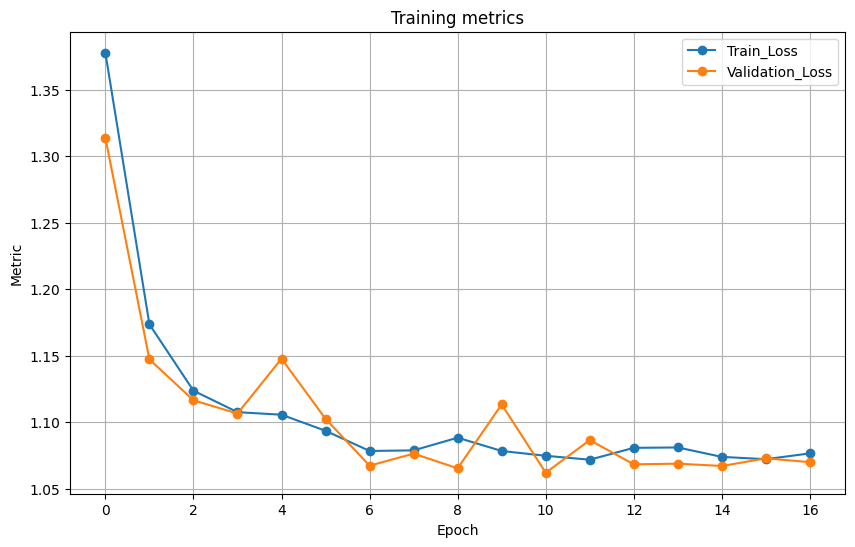

In [10]:
model = SupersimplenetModel(
    backbone="wide_resnet50_2.tv_in1k",
    layers=["layer2", "layer3"],
    perlin_threshold=0.2,
    stop_grad=True,
)

trained_model = train_ssn_with_validation(
    model=model,
    train_dataset=train_dataset,
    validation_dataset=normal_val_dataset,
    visualization_dataset=visualization_dataset,
    num_epochs=num_train_epochs,
    learning_rate=1e-4,
    weight_decay=1e-5,
    device=device,
    log_interval=3,
    log_dir=log_dir,
    batch_size=10,
    resume_from_checkpoint=False,
    freeze_extractor=True,
    early_stopping_patience=6,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min",
)


# Evaluation before classification head fine-tune


In [11]:
before_head_eval_metrics, before_head_eval_rows = evaluate_visual_test(
    trained_model,
    visual_test_classification_dataset,
    log_dir=log_dir,
    image_size=image_size,
    device=device,
    eval_subdir="final_eval_before_head",
)

print(f"Before head fine-tune ROC AUC: {before_head_eval_metrics['image_roc_auc']:.4f}")
print(f"Before head fine-tune average precision: {before_head_eval_metrics['image_avg_precision']:.4f}")
print(f"Before-head visualizations saved to: {os.path.join(log_dir, 'final_eval_before_head', 'visualizations')}")


Before head fine-tune ROC AUC: 0.2958
Before head fine-tune average precision: 0.4110
Before-head visualizations saved to: logs\3D_printer_supersimplenet_head_finetune\try_3\final_eval_before_head\visualizations


# Дообучение classification head


In [ ]:
class BinaryPathDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32), os.path.basename(path)


def make_head_finetune_dataset(normal_dataset, anomaly_dataset, normal_per_anomaly=2, seed=42):
    anomaly_paths = list(anomaly_dataset.image_paths)
    if len(anomaly_paths) == 0:
        raise ValueError("No anomaly images were reserved for classifier-head fine-tuning")

    rng = random.Random(seed)
    normal_paths = list(normal_dataset.image_paths)
    normal_count = min(len(normal_paths), max(1, len(anomaly_paths) * normal_per_anomaly))
    sampled_normal_paths = rng.sample(normal_paths, normal_count)

    items = [(path, 0.0) for path in sampled_normal_paths] + [(path, 1.0) for path in anomaly_paths]
    rng.shuffle(items)
    return BinaryPathDataset(items, transform=normal_dataset.transform)


def set_only_classifier_head_trainable(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.segdec.cls_conv.parameters():
        param.requires_grad = True
    for param in model.segdec.cls_fc.parameters():
        param.requires_grad = True
    get_trainable_parameters(model)


def classifier_head_logits(model, images):
    with torch.no_grad():
        features = model.feature_extractor(images)
        adapted = model.adaptor(features)
    _, pred_score = model.segdec(adapted.detach())
    return pred_score.view(-1)


def evaluate_image_roc_auc(model, dataset, device=device):
    model.eval()
    predicted_scores = []
    true_labels = []
    names = []
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Visual Test ROC AUC", leave=False):
            img, true_label, name = dataset[i]
            img = img.unsqueeze(0).to(device)
            output = model(img)
            predicted_scores.append(output.pred_score.item())
            true_labels.append(true_label)
            names.append(name)
    return roc_auc_score(true_labels, predicted_scores), predicted_scores, true_labels, names


def finetune_classifier_head(
    model,
    head_train_dataset,
    num_epochs=6,
    learning_rate=3e-5,
    weight_decay=1e-4,
    batch_size=8,
    device=device,
    log_dir="../experiments",
):
    model = model.to(device)
    set_only_classifier_head_trainable(model)
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "head_finetune_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)

    labels = [label for _, label in head_train_dataset.items]
    normal_count = max(1, sum(1 for label in labels if label == 0.0))
    anomaly_count = max(1, sum(1 for label in labels if label == 1.0))
    pos_weight = torch.tensor([normal_count / anomaly_count], device=device)

    loader = DataLoader(head_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(get_trainable_parameters(model), lr=learning_rate, weight_decay=weight_decay)

    metrics = {"Head_Train_Loss": []}
    for epoch in range(num_epochs):
        model.train()
        model.feature_extractor.eval()
        model.adaptor.eval()
        model.segdec.seg_head.eval()
        model.segdec.cls_conv.train()
        model.segdec.cls_fc.train()

        total_loss = 0.0
        for images, labels, _ in tqdm(loader, desc=f"Head Epoch {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            labels = labels.to(device).view(-1)

            optimizer.zero_grad()
            logits = classifier_head_logits(model, images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        metrics["Head_Train_Loss"].append(avg_loss)
        print(f"Head epoch {epoch + 1}/{num_epochs} | Loss: {avg_loss:.6f}")

        checkpoint_payload = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": metrics,
            "learning_rate": learning_rate,
        }
        torch.save(checkpoint_payload, os.path.join(checkpoints_dir, "head_checkpoint.pth"))
        torch.save(checkpoint_payload, os.path.join(checkpoints_dir, f"head_checkpoint_epoch_{epoch + 1}.pth"))

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_head_finetuned_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model_head_finetuned.pth"))
    with open(os.path.join(checkpoints_dir, "head_training_metrics.txt"), "w") as f:
        for metric_name, metric_values in metrics.items():
            f.write(f"{metric_name}: {metric_values[-1]}\n")
    plot_training_curves([metrics["Head_Train_Loss"]], ["Head_Train_Loss"], checkpoints_dir, "head_finetune_loss.png")
    return model, metrics


Classifier-head fine-tune dataset size: 51
Reserved visual-test dataset size: 31
Trainable parameters: 4919043
Trainable parameters: 4919043


Head epoch 1/4 | Loss: 0.844466


Head epoch 2/4 | Loss: 0.610765


Head epoch 3/4 | Loss: 0.443596


Head epoch 4/4 | Loss: 0.420561


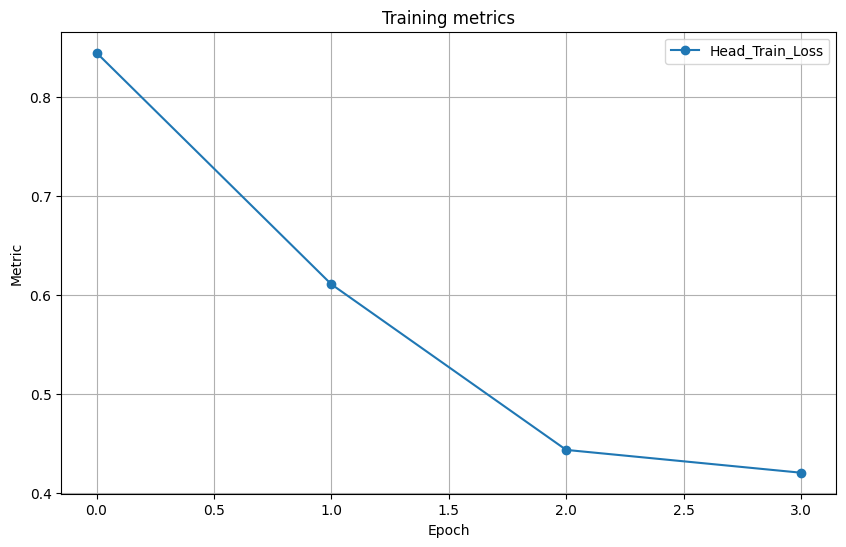

In [13]:
head_train_dataset = make_head_finetune_dataset(
    normal_dataset=train_dataset,
    anomaly_dataset=head_finetune_anomaly_dataset,
    normal_per_anomaly=2,
    seed=random_seed,
)
print(f"Classifier-head fine-tune dataset size: {len(head_train_dataset)}")
print(f"Reserved visual-test dataset size: {len(visual_test_classification_dataset)}")

head_finetuned_model, head_metrics = finetune_classifier_head(
    model=trained_model,
    head_train_dataset=head_train_dataset,
    num_epochs=4,
    learning_rate=3e-5,
    weight_decay=1e-4,
    batch_size=8,
    device=device,
    log_dir=log_dir,
)



# Проверка на аномальных примерах

In [14]:
best_model_path = os.path.join(log_dir, "trained_model_head_finetuned.pth")
best_trained_model = torch.load(best_model_path, weights_only=False, map_location=device)
best_trained_model.to(device)
best_trained_model.eval()

after_head_eval_metrics, after_head_eval_rows = evaluate_visual_test(
    best_trained_model,
    visual_test_classification_dataset,
    log_dir=log_dir,
    image_size=image_size,
    device=device,
    eval_subdir="final_eval_after_head",
)

print(f"After head fine-tune ROC AUC: {after_head_eval_metrics['image_roc_auc']:.4f}")
print(f"After head fine-tune average precision: {after_head_eval_metrics['image_avg_precision']:.4f}")
print(f"After-head visualizations saved to: {os.path.join(log_dir, 'final_eval_after_head', 'visualizations')}")


head_finetune_comparison = compare_head_finetune_metrics(
    before_head_eval_metrics,
    after_head_eval_metrics,
    log_dir=log_dir,
)

print("Head fine-tune comparison:")
for key, value in head_finetune_comparison.items():
    print(f"  {key}: {value}")


After head fine-tune ROC AUC: 0.9292
After head fine-tune average precision: 0.9299
After-head visualizations saved to: logs\3D_printer_supersimplenet_head_finetune\try_3\final_eval_after_head\visualizations
Head fine-tune comparison:
  before_image_roc_auc: 0.29583333333333334
  after_image_roc_auc: 0.9291666666666667
  delta_image_roc_auc: 0.6333333333333333
  before_image_avg_precision: 0.4110479568027907
  after_image_avg_precision: 0.9298763929568883
  delta_image_avg_precision: 0.5188284361540976
  improved_on_both_metrics: True


In [15]:
# Before/after visual-test artifacts are saved in log_dir/final_eval_before_head and log_dir/final_eval_after_head.
